# traQmania 04 — Training the quantum driver

[Notebook 02](02_q_learning_from_scratch.ipynb) built a double-DQN loop;
[notebook 03](03_quantum_circuits_as_q_functions.ipynb) built a 56-parameter
quantum Q-function with fast adjoint gradients. Because both Q-functions speak
the same 4-method protocol, training the quantum driver is a one-line swap.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import matplotlib.pyplot as plt
import numpy as np

## Train the 4-qubit agent, live

400 episodes on the oval with the numpy statevector fast path — around half a
minute on a laptop. Everything else (env, replay, double-DQN, Adam,
$\varepsilon$ schedule) is identical to the classical run.

In [2]:
import time

from traqmania.agents.quantum import QuantumQFunction
from traqmania.agents.training import DQNTrainer
from traqmania.config import load_config
from traqmania.env.racing_env import RacingEnv
from traqmania.env.track import Track
from traqmania.train_headless import CleanLapMonitor

config = load_config()
training_cfg = dict(config["training"])
training_cfg["seed"] = 0

track = Track.load("oval")
env = RacingEnv(track, config, n_envs=training_cfg["n_parallel_envs"], seed=0)
monitor = CleanLapMonitor(env)
qfunc = QuantumQFunction(config["circuit"], seed=0)   # <- the only changed line
trainer = DQNTrainer(qfunc, monitor, training_cfg, rng=np.random.default_rng(0))

t0 = time.perf_counter()
history = trainer.train(episodes=400)
wall = time.perf_counter() - t0
print(f"trained 400 episodes in {wall:.1f} s")
print(f"first clean lap: episode {monitor.first_clean_episode} "
      f"(after {monitor.first_clean_wall_s:.1f} s of training)")
print(f"best lap during training: {monitor.best_lap_s:.1f} s")

trained 400 episodes in 41.4 s
first clean lap: episode 203 (after 7.5 s of training)
best lap during training: 14.4 s


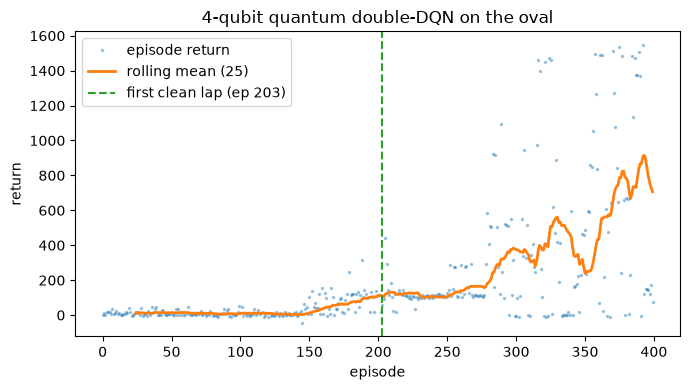

In [3]:
returns = np.array(history["episode_returns"])
window = 25
smooth = np.convolve(returns, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(returns, ".", ms=3, alpha=0.35, label="episode return")
ax.plot(np.arange(window - 1, len(returns)), smooth, lw=2, label=f"rolling mean ({window})")
if monitor.first_clean_episode:
    ax.axvline(monitor.first_clean_episode, color="tab:green", ls="--",
               label=f"first clean lap (ep {monitor.first_clean_episode})")
ax.set(xlabel="episode", ylabel="return", title="4-qubit quantum double-DQN on the oval")
ax.legend()
plt.tight_layout()
plt.show()

A 4-qubit circuit learns to race in well under a minute. But a single seed on a
single track proves nothing — RL is notoriously seed-sensitive.

## Quantum vs classical, across seeds and tracks

The repository ships pre-computed training histories
(`data/histories/*.history.json`): the quantum agent (5 seeds) and the MLP
baseline (4 seeds) trained with identical hyperparameters on all three tracks.
We plot the per-episode return, smoothed per seed, as **mean ± one standard
deviation across seeds**.

In [4]:
import json
import re
from pathlib import Path

hist_dir = next((b / "data" / "histories" for b in [Path.cwd(), *Path.cwd().parents]
                 if (b / "data" / "histories").is_dir()), None)
print("histories:", hist_dir)

runs = {}  # (agent, track) -> list of return arrays
laps = {}  # (agent, track) -> list of (best_lap_s, first_clean_episode)
if hist_dir is not None:
    pat = re.compile(r"^(hero|mlp)_(oval|chicane|gp)_s(\d+)\.history\.json$")
    for f in sorted(hist_dir.iterdir()):
        m = pat.match(f.name)
        if not m:
            continue
        agent = {"hero": "quantum", "mlp": "classical MLP"}[m.group(1)]
        data = json.loads(f.read_text())
        runs.setdefault((agent, m.group(2)), []).append(np.array(data["episode_returns"]))
        laps.setdefault((agent, m.group(2)), []).append(
            (data["best_lap_s"], data["first_clean_episode"]))
    for (agent, track_name), arrs in sorted(runs.items()):
        n_eps = min(len(a) for a in arrs)
        print(f"{agent:>13} on {track_name:<8} {len(arrs)} seeds x {n_eps} episodes")
else:
    print("data/histories not found (running outside the repo checkout) "
          "-- skipping the comparison plots")

histories: /Users/majl/GitHub/traQmania/data/histories
classical MLP on chicane  4 seeds x 3000 episodes
classical MLP on gp       4 seeds x 6000 episodes
classical MLP on oval     4 seeds x 3000 episodes
      quantum on chicane  5 seeds x 3000 episodes
      quantum on gp       5 seeds x 6000 episodes
      quantum on oval     5 seeds x 3000 episodes


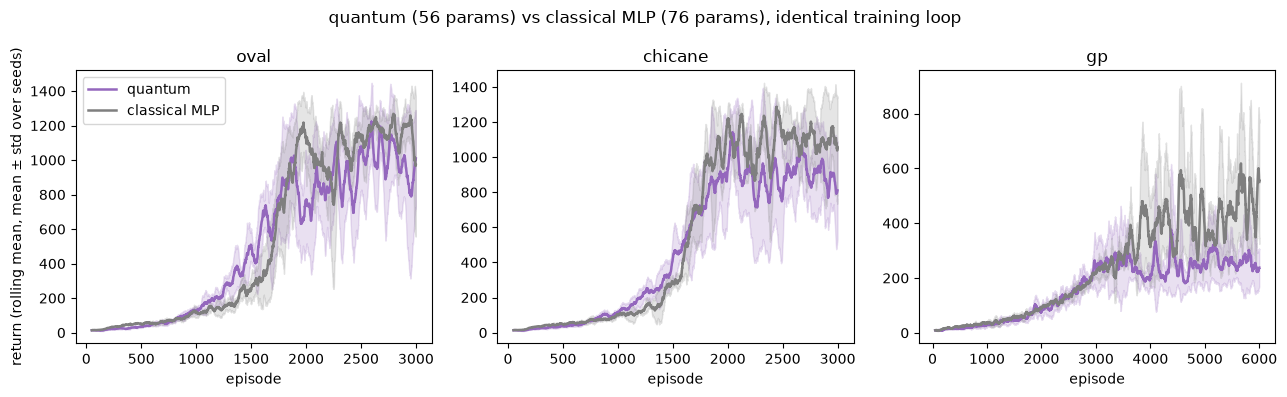

In [5]:
def band(arrs, window=51):
    n = min(len(a) for a in arrs)
    kernel = np.ones(window) / window
    smoothed = np.stack([np.convolve(a[:n], kernel, mode="valid") for a in arrs])
    x = np.arange(window - 1, n)
    return x, smoothed.mean(axis=0), smoothed.std(axis=0)


if runs:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
    for ax, track_name in zip(axes, ("oval", "chicane", "gp"), strict=True):
        for agent, color in (("quantum", "tab:purple"), ("classical MLP", "tab:gray")):
            x, mean, std = band(runs[(agent, track_name)])
            ax.plot(x, mean, color=color, lw=1.8, label=agent)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
        ax.set(title=track_name, xlabel="episode")
    axes[0].set_ylabel("return (rolling mean, mean ± std over seeds)")
    axes[0].legend()
    fig.suptitle("quantum (56 params) vs classical MLP (76 params), identical training loop")
    plt.tight_layout()
    plt.show()

## Lap times

Returns measure training progress; racers care about lap time. Per agent and
track, over all seeds:

In [6]:
if laps:
    print(f"{'track':<10}{'agent':<16}{'seeds':>6}{'best lap':>10}{'median lap':>12}"
          f"{'median first clean ep':>24}")
    for track_name in ("oval", "chicane", "gp"):
        for agent in ("quantum", "classical MLP"):
            rows = laps[(agent, track_name)]
            best = np.array([r[0] for r in rows], dtype=float)
            first = np.array([r[1] for r in rows], dtype=float)
            print(f"{track_name:<10}{agent:<16}{len(rows):>6}{best.min():>9.1f}s"
                  f"{np.median(best):>11.1f}s{np.median(first):>24.0f}")

track     agent            seeds  best lap  median lap   median first clean ep
oval      quantum              5     13.5s       13.7s                     821
oval      classical MLP        4     13.9s       14.6s                     779
chicane   quantum              5     13.8s       13.8s                     871
chicane   classical MLP        4     14.7s       15.1s                     906
gp        quantum              5     19.9s       21.3s                    1930
gp        classical MLP        4     19.8s       20.4s                    2780


## What this does — and does not — show

Being honest matters more than being exciting:

- **It shows parity, not speedup.** A 56-parameter quantum circuit and a
  76-parameter MLP learn the same task, at broadly similar sample efficiency,
  reaching comparable lap times (the quantum agent happens to edge ahead on
  oval/chicane lap time, the MLP on gp — differences of a few percent, within
  seed noise). That a VQC *can* do this is the point, echoing Chen et al.
  (2020) and Skolik et al. (2022).
- **No quantum advantage is claimed or possible here.** Four qubits are
  trivially simulable — training *ran* on a classical simulation of the
  circuit. Claims of RL advantage would need problem classes where the quantum
  model provably captures structure a comparably-sized classical model cannot
  (see e.g. Jerbi et al. 2021 for constructed examples), not a racing toy.
- **Watch the denominators.** "Similar sample efficiency" is per *episode*;
  per *second* the MLP trains faster (cheaper gradients). And parameter count
  is an imperfect fairness measure — expressivity per parameter differs.
- **What it is:** an end-to-end, reproducible, laptop-scale testbed where the
  quantum model is a drop-in for the classical one — which is exactly what you
  need before asking sharper questions.


## Scaling the circuit: 4 vs 6 qubits

[Notebook 03](03_quantum_circuits_as_q_functions.ipynb) generalized the
circuit to $n$ qubits; the `q6` profile gives the driver 5 lidar rays instead
of 3 (one feature per qubit, actions stay 4) at $P = 3Ln + 8 = 80$ parameters
instead of 56 — 43% more. Does the wider sensor array learn faster, or drive
better? The repo ships three 6-qubit oval runs
(`data/histories/q6_oval_s*.history.json`, seeds 0/1/42, 600 episodes) trained
with the **same default schedule as the live 4-qubit run at the top of this
notebook**, so that run is the like-for-like reference. The 5-seed hero
histories above are not: those are 3000-episode runs with a slower exploration
schedule (first clean lap only around episode 800), good for the long-run
asymptote, not for take-off speed.


6-qubit oval runs: seeds [0, 1, 42]


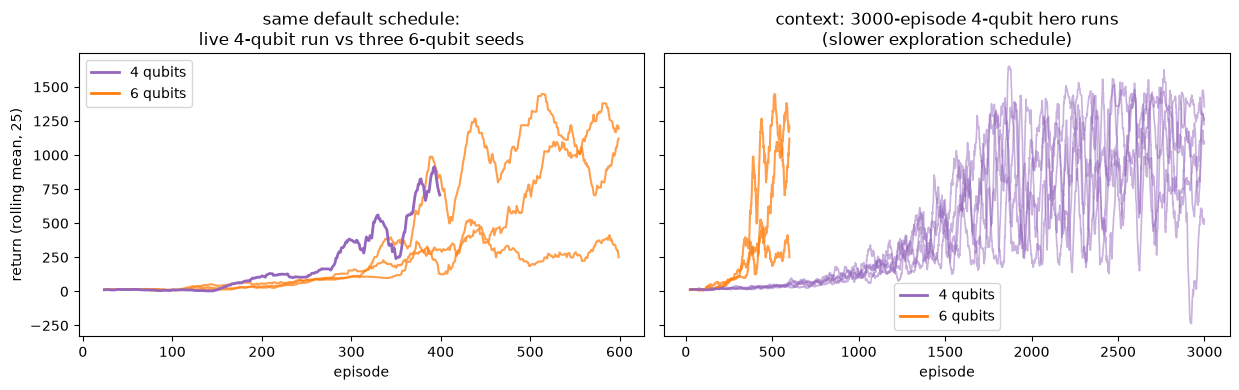

In [7]:
q6_runs = []
if hist_dir is not None:
    q6_runs = sorted((json.loads(f.read_text())
                      for f in hist_dir.glob("q6_oval_s*.history.json")),
                     key=lambda d: d["seed"])
    print("6-qubit oval runs: seeds", [d["seed"] for d in q6_runs])

if q6_runs:
    def smooth25(returns):
        r = np.asarray(returns, dtype=float)
        return np.arange(24, len(r)), np.convolve(r, np.ones(25) / 25, mode="valid")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)
    for d in q6_runs:
        x, s = smooth25(d["episode_returns"])
        ax1.plot(x, s, color="tab:orange", lw=1.5, alpha=0.75)
        ax2.plot(x, s, color="tab:orange", lw=1.5, alpha=0.75)
    x, s = smooth25(history["episode_returns"])  # the live 4-qubit run from above
    ax1.plot(x, s, color="tab:purple", lw=2.0)
    ax1.set(xlabel="episode", ylabel="return (rolling mean, 25)",
            title="same default schedule:\nlive 4-qubit run vs three 6-qubit seeds")
    for r in runs.get(("quantum", "oval"), []):
        x, s = smooth25(r)
        ax2.plot(x, s, color="tab:purple", lw=1.2, alpha=0.5)
    ax2.set(xlabel="episode",
            title="context: 3000-episode 4-qubit hero runs\n(slower exploration schedule)")
    for ax in (ax1, ax2):
        ax.legend(handles=[plt.Line2D([], [], color="tab:purple", lw=2, label="4 qubits"),
                           plt.Line2D([], [], color="tab:orange", lw=2, label="6 qubits")])
    plt.tight_layout()
    plt.show()


In [8]:
if q6_runs:
    q6_params = QuantumQFunction(load_config("q6")["circuit"]).n_params
    rows = [("4 qubits (live run above)", qfunc.n_params, monitor.first_clean_episode,
             monitor.first_clean_wall_s, monitor.best_lap_s)]
    rows += [(f"6 qubits, seed {d['seed']}", q6_params, d["first_clean_episode"],
              d["first_clean_wall_s"], d["best_lap_s"]) for d in q6_runs]
    print(f"{'run':<28}{'params':>7}{'first clean lap':>17}{'wall to 1st lap':>17}{'best lap':>10}")
    for name, n_params, ep, wall, lap in rows:
        print(f"{name:<28}{n_params:>7}{f'ep {ep}':>17}{wall:>15.1f} s{lap:>9.1f}s")


run                          params  first clean lap  wall to 1st lap  best lap
4 qubits (live run above)        56           ep 203            7.5 s     14.4s
6 qubits, seed 0                 80           ep 352           31.1 s     16.1s
6 qubits, seed 1                 80           ep 311           28.3 s     14.4s
6 qubits, seed 42                80           ep 286           28.1 s     14.8s


What the numbers say — honestly:

- **Same sample efficiency.** On the default schedule, both widths need a few
  hundred episodes to a first clean lap (6-qubit seeds 42/1/0: episodes
  286/311/352 — see the table). The 43% extra parameters and 5-instead-of-3
  rays neither help nor hurt learning on the oval.
- **Wall-clock is a different story.** In the scaling runs the first lap took
  ~11 s of 4-qubit training vs ~28 s at 6 qubits: a 6-qubit statevector has 64
  amplitudes instead of 16, so every forward/backward pass costs about 4× more
  (and the 6-qubit runs additionally shared the machine three-at-a-time).
  Per-episode compute, not learning speed, drives the gap.
- **No lap-time win either.** The 4-qubit agent's best lap (14.4 s in the live
  run above) matches the 6-qubit runs — 14.4–16.1 s during training across
  seeds, and the bundled 6-qubit weights greedy-verify at 14.7 s over 24 laps.
  On the oval, three rays already see everything that matters. Treat this as a
  real scaling data point, not a success story: the open question is whether
  wider sensor arrays pay off on tracks that actually demand them.

**Next:** [05 — Real quantum hardware](05_real_quantum_hardware.ipynb) takes the
trained weights off the exact simulator: shots, device noise, and IBM Quantum
backends.